# 02 — Prophet forecast model

Builds the v1 forecasting model. Prophet was chosen over a gradient-boosted
model (LightGBM) specifically because this problem is dominated by yearly
and weekly seasonal cycles with no complex feature interactions to model —
see `docs/adr/0002-prophet-over-lightgbm.md` for the full reasoning.

This notebook: (1) decomposes one series into trend/yearly/weekly
components to confirm Prophet is actually picking up the seasonality,
(2) backtests on a representative series per category, (3) batch-trains
all 500 store-item combinations, (4) writes down what this model
**cannot** do — the limitations that motivate v2.

In [1]:
import sys

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

sys.path.insert(0, "..")

import cmdstanpy

from src.demand_advisor import data as data_mod
from src.demand_advisor import forecast as fc

# To disable logging globally for the session:
cmdstanpy.disable_logging()

df = data_mod.load_processed()
print(f"{len(df):,} rows loaded")

Importing plotly failed. Interactive plots will not work.


913,000 rows loaded


## Decompose one series — item 1, store 1 (winter apparel)

This is the core check: does Prophet actually recover the yearly/weekly cycles we designed into the data, without being told anything about categories or seasons up front?

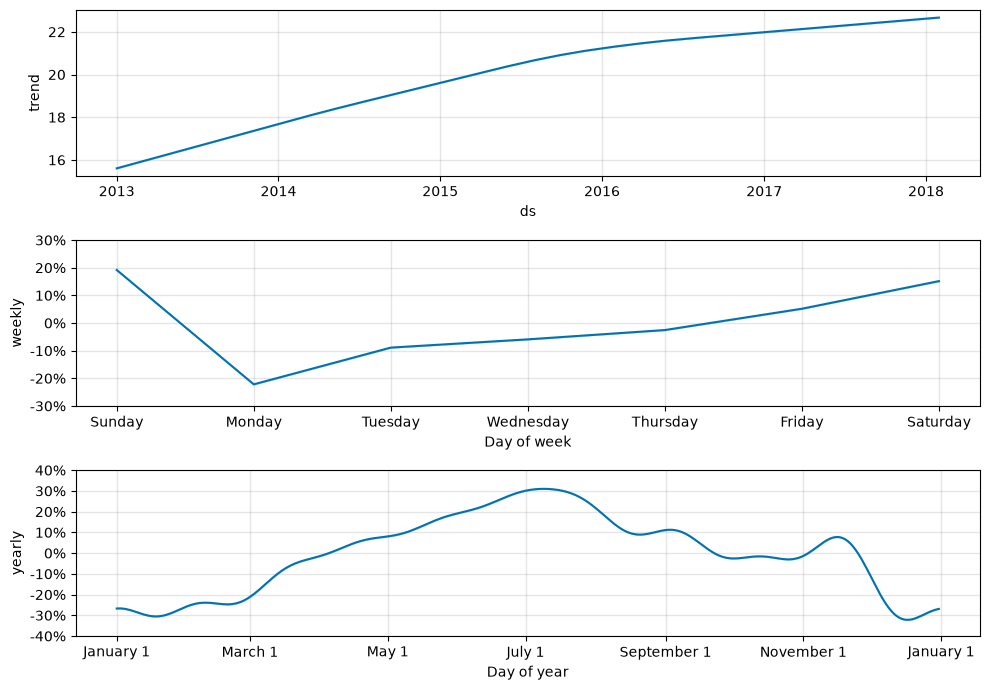

In [2]:
pdf = fc.to_prophet_frame(df, store=1, item=1)
model = fc.train(pdf)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

fig = model.plot_components(forecast)
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

The yearly component should peak around December/January and trough around June/July for this item — matching the winter-apparel seasonality built into the synthetic data. The weekly component should show a Saturday/Sunday lift. Prophet found both from raw daily sales alone, which is exactly the property that makes it a good fit here.

## Backtest — one representative series per category

Time-based split (last 90 days held out), scored with WAPE (weighted absolute percentage error) rather than plain MAPE, which is unstable when actual sales are near zero on many days.

In [3]:
representative = {
    1: "winter (parka)", 12: "summer (flip flops)",
    43: "back-to-school (notebook)", 26: "holiday (candle set)",
    17: "flat (frying pan)",
}

rows = []
for item_id, label in representative.items():
    pdf_i = fc.to_prophet_frame(df, store=1, item=item_id)
    result = fc.backtest(pdf_i, holdout_days=90)
    rows.append({"item": item_id, "category": label,
                 "wape": round(result["wape"], 3), "mae": round(result["mae"], 2)})

backtest_summary = pd.DataFrame(rows)
backtest_summary

,item,category,wape,mae
0,1,winter (parka),0.186,3.79
1,12,summer (flip flops),0.091,6.03
2,43,back-to-school (notebook),0.136,6.51
3,26,holiday (candle set),0.130,6.03
4,17,flat (frying pan),0.137,4.23


### Actual vs. forecast on the holdout window, two examples

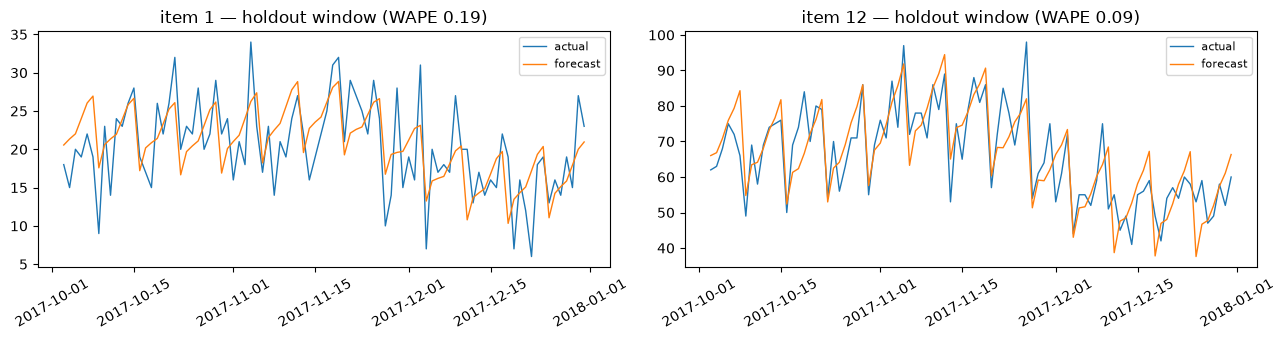

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, item_id in zip(axes, [1, 12]):
    pdf_i = fc.to_prophet_frame(df, store=1, item=item_id)
    result = fc.backtest(pdf_i, holdout_days=90)
    test_df = result["test_df"]
    ax.plot(test_df["ds"], test_df["y"], label="actual", linewidth=1)
    ax.plot(test_df["ds"], test_df["yhat"], label="forecast", linewidth=1)
    ax.set_title(f"item {item_id} — holdout window (WAPE {result['wape']:.2f})")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Batch train — all 500 store-item combinations

One Prophet model per (store, item), trained on full history, saved via `model_to_json` (Prophet's own recommended serialization, not raw pickle — see `skills/forecasting-model-io.md`). This takes a few minutes; it's a one-time offline step, not something run per request.

In [9]:
summary = fc.batch_train_all(df)

print(f"trained and saved {len(summary)} models to ../models/prophet/")
summary.head()

trained and saved 500 models to ../models/prophet/


,store,item,n_days,mean_daily_sales,artifact
0,1,1,1826,19.971522,/home/terror/demand-reorder-advisor/models/pro...
1,1,2,1826,53.148959,/home/terror/demand-reorder-advisor/models/pro...
2,1,3,1826,33.208105,/home/terror/demand-reorder-advisor/models/pro...
3,1,4,1826,19.956188,/home/terror/demand-reorder-advisor/models/pro...
4,1,5,1826,16.612815,/home/terror/demand-reorder-advisor/models/pro...


In [10]:
summary.describe()[["n_days", "mean_daily_sales"]]

,n_days,mean_daily_sales
count,500.0,500.000000
mean,1826.0,52.250287
std,0.0,24.062536
min,1826.0,12.733844
25%,1826.0,30.964266
50%,1826.0,50.030942
75%,1826.0,69.348987
max,1826.0,112.638007


## Sanity check — load a saved model back and predict

In [11]:
reloaded = fc.load_model(store=3, item=26)  # holiday item, large-format store
future = reloaded.make_future_dataframe(periods=14)
next_two_weeks = reloaded.predict(future).tail(14)[["ds", "yhat"]]
next_two_weeks["yhat"] = next_two_weeks["yhat"].round(1)
next_two_weeks

,ds,yhat
1826,2018-01-01,30.7
1827,2018-01-02,38.5
1828,2018-01-03,38.8
1829,2018-01-04,43.3
1830,2018-01-05,46.7
1831,2018-01-06,51.2
1832,2018-01-07,55.1
1833,2018-01-08,30.6
1834,2018-01-09,38.4
1835,2018-01-10,38.9


## Log this run to MLflow

Wired in now, on the same notebook that trained the models. Local file store, no server required. See `skills/mlflow-tracking-patterns.md`.

In [14]:
from src.demand_advisor import tracking

prophet_kwargs = {
    "yearly_seasonality": True,
    "weekly_seasonality": True,
    "daily_seasonality": False,
    "seasonality_mode": "multiplicative",
}

run_id = tracking.log_batch_run(
    prophet_kwargs=prophet_kwargs,
    holdout_days=90,
    backtest_summary=backtest_summary,
    batch_summary=summary,
    model_dir=fc.MODEL_DIR,
)
print(f"logged MLflow run: {run_id}")
print("view with: uv run python -m mlflow ui --backend-store-uri sqlite:///mlflow.db")

logged MLflow run: adaf3e53032540549939c3b4a762179b
view with: uv run python -m mlflow ui --backend-store-uri sqlite:///mlflow.db


## Limitations of this v1 model — before building the agent

The project's build philosophy
(`docs/Problem_brief.md`): complexity gets added in response to a documented
limitation, not in advance of one.

1. **Prophet has no concept of company policy.** It will happily forecast
   continued demand for item 7 (discontinued — safety recall) or item 40
   (regulatory hold) because historically they sold fine. The forecast
   alone is not a reorder decision — this is exactly why the policy RAG
   layer and MCP inventory lookup exist in the v1 agent design, not as
   optional extras.
2. **Prophet has no concept of current inventory.** A high forecast for an
   item that's already overstocked should not trigger a reorder — the
   inventory lookup has to sit between the forecast and any recommendation.
3. **Per-series independence.** Each (store, item) model is trained alone —
   there's no cross-item substitution effect (e.g. a stockout on one
   sunscreen SKU pushing demand to another) and no cross-store transfer
   logic. Acceptable for v1; worth revisiting if v2's limitations point here.
4. **No shock/promotion awareness.** Prophet extrapolates from historical
   seasonal patterns; a demand spike from a promotion or news event with no
   historical precedent will be missed until enough new data accumulates.
5. **WAPE varies noticeably by category** (see the backtest table above) —
   sharply seasonal, narrow-window items (back-to-school, holiday) are
   harder to forecast precisely at the edges of their season than flat,
   year-round items. Worth tracking per-category accuracy going forward,
   not just an overall average that would hide this.

None of these are reasons to abandon Prophet for v1 — they're the
documented boundary of what a pure forecasting model can responsibly claim,
which is precisely the point of building v1.